In [ ]:
from google.colab import drive
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/DGM_HW3/Part1_EBM'
CHECKPOINT_DIR = os.path.join(BASE_PATH, 'checkpoints')
RESULTS_DIR = os.path.join(BASE_PATH, 'results')

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Mounted at /content/drive
Using device: cuda


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

In [ ]:
from torchvision.utils import make_grid
def show_and_save_batch(loader, title):
    images, _ = next(iter(loader))
    images = images[:32]
    grid_img = make_grid(images, nrow=8, normalize=True, value_range=(0, 1))

    plt.figure(figsize=(10, 5))
    plt.imshow(grid_img.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.title(title)
    plt.axis('off')

    plt.show()

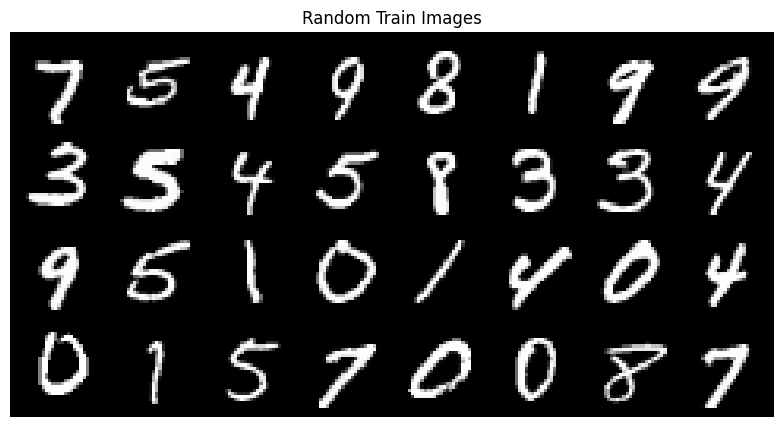

In [ ]:
#Random Train Images
show_and_save_batch(train_loader, "Random Train Images")

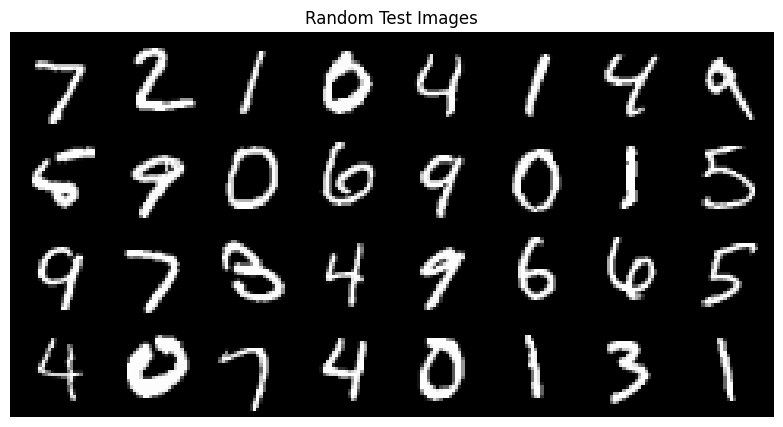

In [ ]:
#Random Test Images
show_and_save_batch(test_loader, "Random Test Images")

In [ ]:
import torch.nn as nn

class EBM(nn.Module):
    def __init__(self):
        super(EBM, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2),

            nn.AdaptiveAvgPool2d(1)
        )

        self.linear = nn.Linear(128, 1)

    def forward(self, x):
        features = self.features(x)
        features_flat = features.view(features.size(0), -1)
        energy = self.linear(features_flat)
        return energy

In [ ]:
# Initialize Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EBM().to(device)
print("Model Architecture Created Successfully based on Table 1.")

Model Architecture Created Successfully based on Table 1.


In [ ]:
def langevin_sampling(model, x_curr, steps=60, step_size=10, noise_scale=0.005):
    x_curr = x_curr.clone().detach().requires_grad_(True)

    for i in range(steps):
        energy = model(x_curr)

        grad = torch.autograd.grad(energy.sum(), x_curr)[0]

        with torch.no_grad():
            noise = torch.randn_like(x_curr) * noise_scale
            x_curr = x_curr - step_size * grad + noise
            x_curr = torch.clamp(x_curr, 0, 1)

        x_curr.requires_grad_(True)

    return x_curr.detach()

Starting training from scratch.
Starting Training...
Epoch [0/10] Step [0] Loss: -0.0013 | E_real: 0.03 | E_fake: 0.03
Epoch [0/10] Step [100] Loss: 0.0001 | E_real: -1.97 | E_fake: -1.96
Epoch [0/10] Step [200] Loss: -0.0494 | E_real: -1.44 | E_fake: -1.39
Epoch [0/10] Step [300] Loss: 0.0918 | E_real: -1.50 | E_fake: -1.59
Epoch [0/10] Step [400] Loss: 0.0374 | E_real: -1.32 | E_fake: -1.35
Epoch [0/10] Step [500] Loss: 0.0937 | E_real: -0.93 | E_fake: -1.03
Epoch [0/10] Step [600] Loss: -0.1432 | E_real: -0.83 | E_fake: -0.69
Epoch [0/10] Step [700] Loss: 0.0238 | E_real: -0.93 | E_fake: -0.95
Epoch [0/10] Step [800] Loss: 0.1223 | E_real: -0.65 | E_fake: -0.77
Epoch [0/10] Step [900] Loss: -0.2542 | E_real: -0.44 | E_fake: -0.18
=== End Epoch 0 === Time: 138.8s
Avg Loss: -0.0140 | Avg E_real: -1.1051 | Avg E_fake: -1.0881
Saving generated samples for Epoch 0...


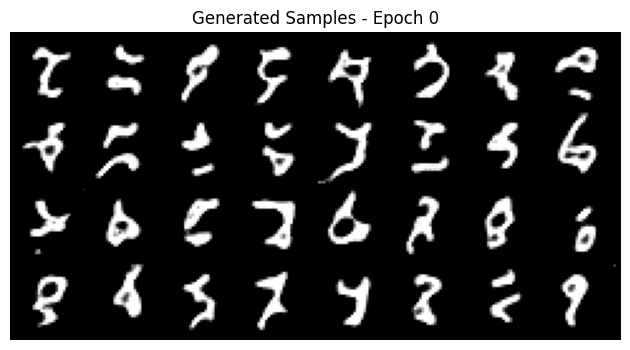

Epoch [1/10] Step [0] Loss: 0.0015 | E_real: -1.08 | E_fake: -1.08
Epoch [1/10] Step [100] Loss: 0.0421 | E_real: -0.96 | E_fake: -1.00
Epoch [1/10] Step [200] Loss: 0.7182 | E_real: -0.34 | E_fake: -1.05
Epoch [1/10] Step [300] Loss: 0.0366 | E_real: -0.98 | E_fake: -1.01
Epoch [1/10] Step [400] Loss: 0.0564 | E_real: -0.85 | E_fake: -0.90
Epoch [1/10] Step [500] Loss: -0.1967 | E_real: -0.61 | E_fake: -0.41
Epoch [1/10] Step [600] Loss: -0.0640 | E_real: -0.50 | E_fake: -0.43
Epoch [1/10] Step [700] Loss: -0.0826 | E_real: -0.60 | E_fake: -0.52
Epoch [1/10] Step [800] Loss: -0.1346 | E_real: -0.55 | E_fake: -0.41
Epoch [1/10] Step [900] Loss: -0.0471 | E_real: -0.38 | E_fake: -0.33
=== End Epoch 1 === Time: 136.3s
Avg Loss: -0.0092 | Avg E_real: -0.6755 | Avg E_fake: -0.6652
Epoch [2/10] Step [0] Loss: -0.1044 | E_real: -0.51 | E_fake: -0.41
Epoch [2/10] Step [100] Loss: 0.1037 | E_real: -0.53 | E_fake: -0.64
Epoch [2/10] Step [200] Loss: 0.0078 | E_real: -0.39 | E_fake: -0.40
Epoch 

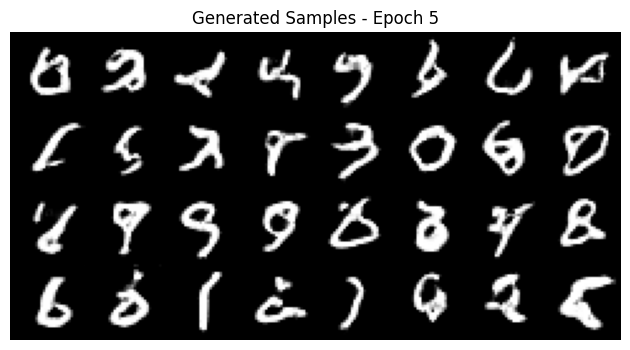

Epoch [6/10] Step [0] Loss: -0.0060 | E_real: -0.24 | E_fake: -0.24
Epoch [6/10] Step [100] Loss: 0.0929 | E_real: -0.13 | E_fake: -0.23
Epoch [6/10] Step [200] Loss: -0.0037 | E_real: -0.26 | E_fake: -0.26
Epoch [6/10] Step [300] Loss: -0.1346 | E_real: -0.06 | E_fake: 0.07
Epoch [6/10] Step [400] Loss: -0.0234 | E_real: -0.04 | E_fake: -0.02
Epoch [6/10] Step [500] Loss: -0.0041 | E_real: -0.03 | E_fake: -0.02
Epoch [6/10] Step [600] Loss: -0.0284 | E_real: 0.17 | E_fake: 0.19
Epoch [6/10] Step [700] Loss: 0.0357 | E_real: -0.40 | E_fake: -0.44
Epoch [6/10] Step [800] Loss: -0.0497 | E_real: 0.13 | E_fake: 0.18
Epoch [6/10] Step [900] Loss: -0.0812 | E_real: 0.12 | E_fake: 0.20
=== End Epoch 6 === Time: 136.0s
Avg Loss: -0.0052 | Avg E_real: -0.0486 | Avg E_fake: -0.0433
Epoch [7/10] Step [0] Loss: -0.0098 | E_real: 0.09 | E_fake: 0.10
Epoch [7/10] Step [100] Loss: 0.0337 | E_real: 0.02 | E_fake: -0.01
Epoch [7/10] Step [200] Loss: 0.1130 | E_real: 0.09 | E_fake: -0.02
Epoch [7/10] S

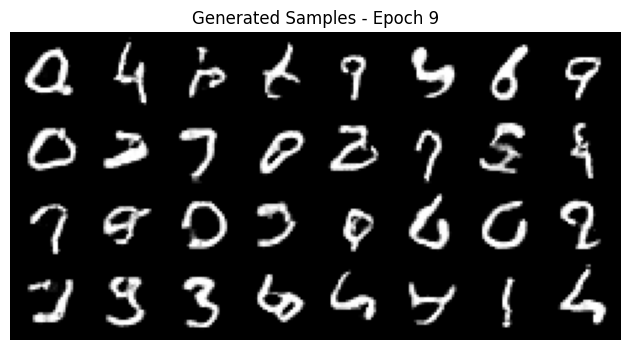

Training Finished.


In [ ]:
#training
import torch.optim as optim
import time
from torchvision.utils import make_grid

n_epochs = 10
lr = 1e-4
reg_lambda = 1e-3
langevin_steps = 60
step_size = 10.0
noise_scale = 0.005

optimizer = optim.Adam(model.parameters(), lr=lr)

checkpoint_path = os.path.join(BASE_PATH, 'ebm_checkpoint.pth')
start_epoch = 0
loss_history = []

if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    loss_history = checkpoint['loss_history']
    print(f"Resumed from Epoch {start_epoch}")
else:
    print("Starting training from scratch.")

print("Starting Training...")
for epoch in range(start_epoch, n_epochs):
    epoch_loss_sum = 0
    epoch_real_energy = 0
    epoch_fake_energy = 0
    start_time = time.time()

    for batch_idx, (real_imgs, _) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # Generate Fake Samples (Langevin)
        x_init = torch.rand(batch_size, 1, 28, 28).to(device)

        fake_imgs = langevin_sampling(model, x_init,
                                      steps=langevin_steps,
                                      step_size=step_size,
                                      noise_scale=noise_scale)

        # Calculate Loss (Algorithm 1)
        optimizer.zero_grad()

        energy_real = model(real_imgs).squeeze()
        energy_fake = model(fake_imgs).squeeze()

        # Data Term: mean(E_real) - mean(E_fake)
        data_term = energy_real.mean() - energy_fake.mean()

        # Regularization Term: lambda * (mean(E_real^2) + mean(E_fake^2))
        reg_term = reg_lambda * ((energy_real**2).mean() + (energy_fake**2).mean())

        loss = data_term + reg_term

        # Backward & Step
        loss.backward()
        optimizer.step()

        # Logging
        epoch_loss_sum += loss.item()
        epoch_real_energy += energy_real.mean().item()
        epoch_fake_energy += energy_fake.mean().item()

        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch}/{n_epochs}] Step [{batch_idx}] Loss: {loss.item():.4f} | E_real: {energy_real.mean().item():.2f} | E_fake: {energy_fake.mean().item():.2f}")

    # End of Epoch Stats
    avg_loss = epoch_loss_sum / len(train_loader)
    avg_real = epoch_real_energy / len(train_loader)
    avg_fake = epoch_fake_energy / len(train_loader)
    loss_history.append(avg_loss)

    print(f"=== End Epoch {epoch} === Time: {time.time()-start_time:.1f}s")
    print(f"Avg Loss: {avg_loss:.4f} | Avg E_real: {avg_real:.4f} | Avg E_fake: {avg_fake:.4f}")

    # Save Checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss_history': loss_history
    }, checkpoint_path)

    # Visualization (Start, Middle, End)
    if epoch == 0 or epoch == n_epochs//2 or epoch == n_epochs-1:
        print(f"Saving generated samples for Epoch {epoch}...")

        grid_fake = make_grid(fake_imgs[:32], nrow=8, normalize=True, value_range=(0,1))
        plt.figure(figsize=(10, 4))
        plt.imshow(grid_fake.permute(1, 2, 0).cpu().numpy(), cmap='gray')
        plt.title(f"Generated Samples - Epoch {epoch}")
        plt.axis('off')

        save_path = os.path.join(RESULTS_DIR, f"generated_epoch_{epoch}.png")
        plt.savefig(save_path)
        plt.show()

print("Training Finished.")

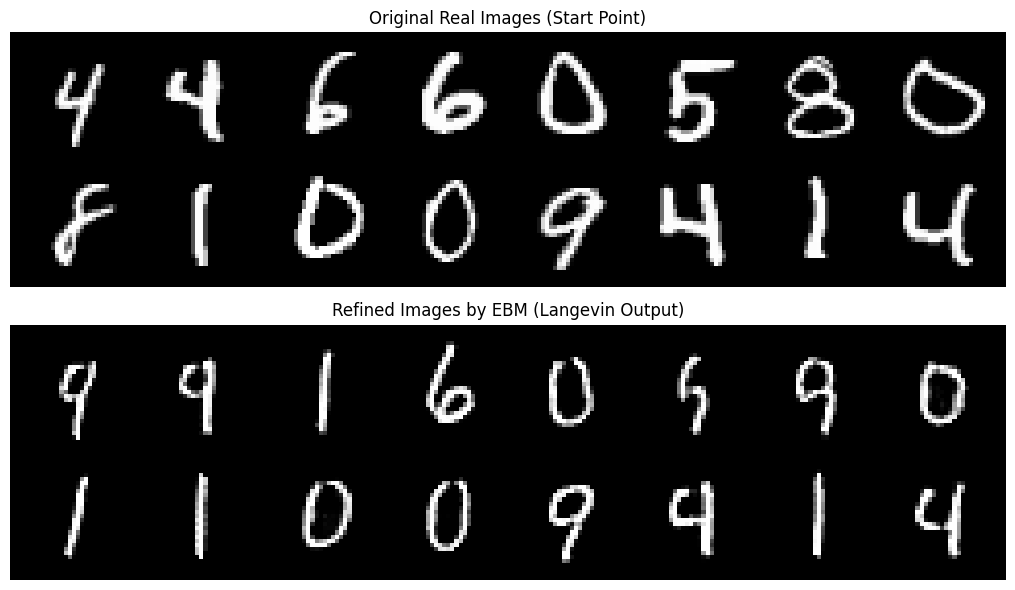

In [ ]:
# Post-Training Analysis (Real vs Refined)
real_batch, _ = next(iter(train_loader))
real_batch = real_batch[:16].to(device)

refined_batch = langevin_sampling(model, real_batch, steps=60, step_size=step_size, noise_scale=noise_scale)

real_grid = make_grid(real_batch, nrow=8, normalize=True, value_range=(0,1))
refined_grid = make_grid(refined_batch, nrow=8, normalize=True, value_range=(0,1))

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.imshow(real_grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
plt.title("Original Real Images (Start Point)")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(refined_grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
plt.title("Refined Images by EBM (Langevin Output)")
plt.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "real_vs_refined.png"))
plt.show()

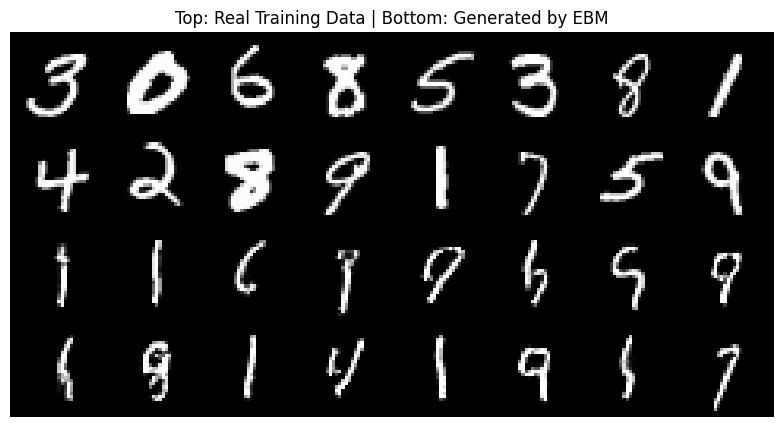

In [ ]:
# Image Generation
n_samples = 16
gen_steps = 100

x_seed = torch.rand(n_samples, 1, 28, 28).to(device)

model.eval()
x_generated = langevin_sampling(model, x_seed, steps=gen_steps, step_size=10, noise_scale=0.005)

real_batch, _ = next(iter(train_loader))
real_batch = real_batch[:n_samples].to(device)

# Visualize and Save
comparison = torch.cat([real_batch, x_generated], dim=0)
grid_comp = make_grid(comparison, nrow=8, normalize=True, value_range=(0,1))

plt.figure(figsize=(10, 5))
plt.imshow(grid_comp.permute(1, 2, 0).cpu().numpy(), cmap='gray')
plt.title("Top: Real Training Data | Bottom: Generated by EBM")
plt.axis('off')

# save_path = os.path.join(RESULTS_DIR, "generation_comparison.png")
# plt.savefig(save_path)
plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\s'
<>:24: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3823643400.py:24: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Denoising (Noise $\sigma={sigma}$)\nTop: Real | Middle: Noisy | Bottom: Denoised")


Denoising with Noise Level (sigma) = 0.2 ---


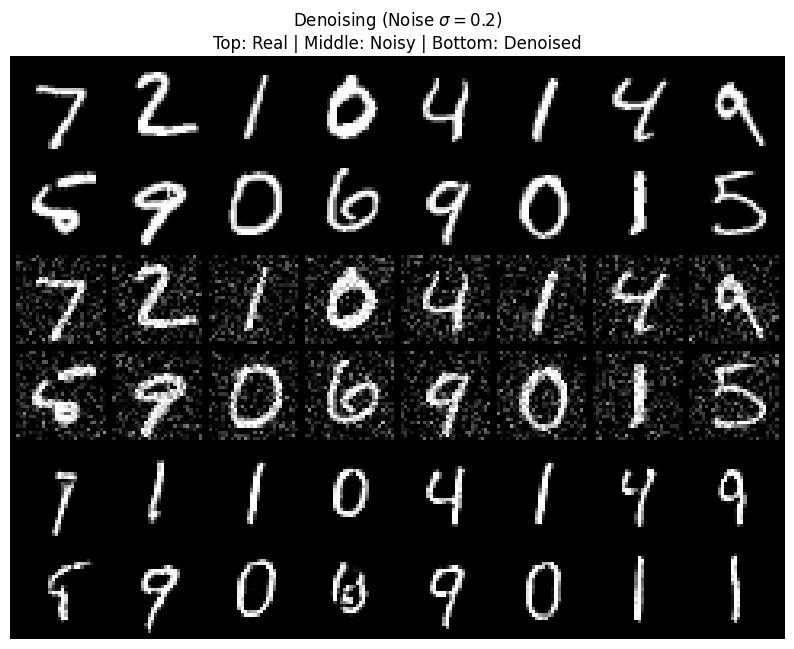

Denoising with Noise Level (sigma) = 0.4 ---


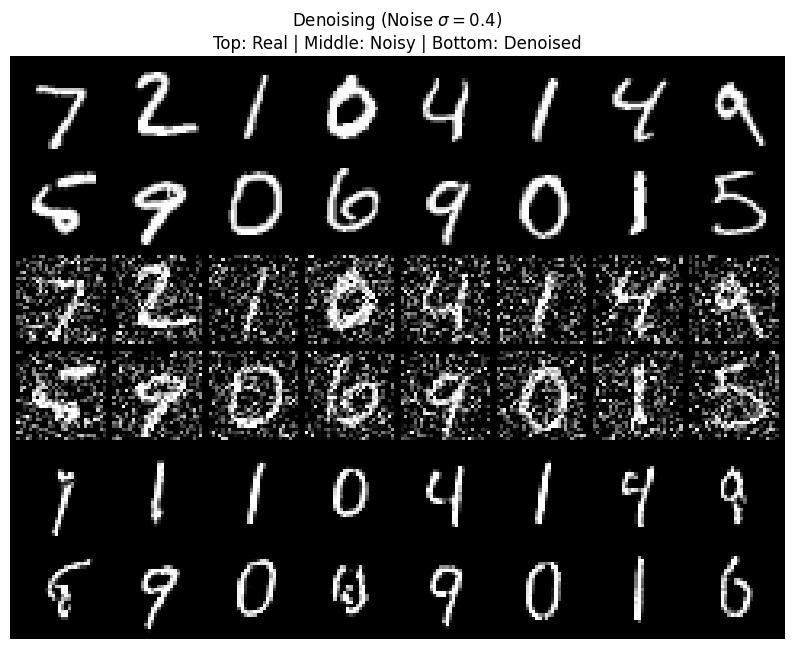

Denoising with Noise Level (sigma) = 0.6 ---


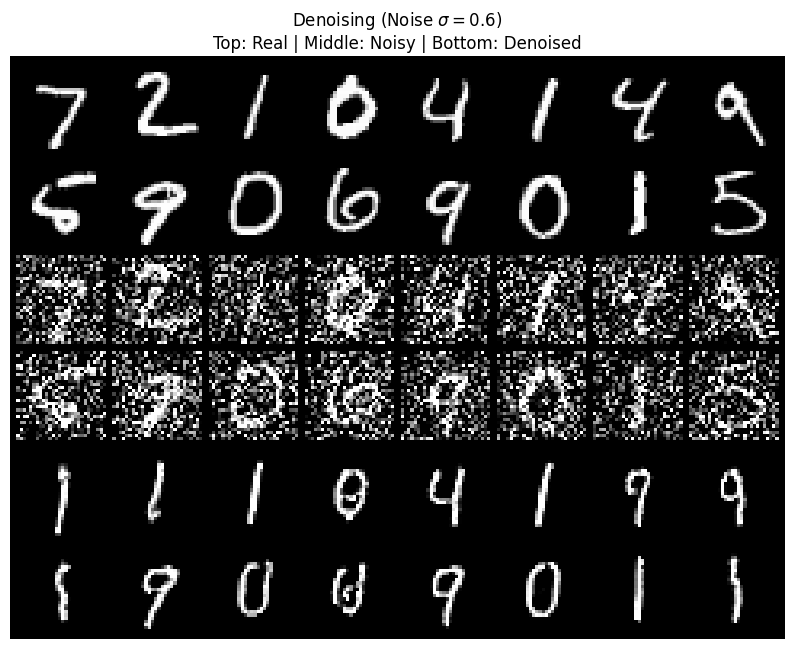

In [ ]:
# Image Denoising
test_batch, _ = next(iter(test_loader))
test_batch = test_batch[:16].to(device)

noise_levels = [0.2, 0.4, 0.6]

for sigma in noise_levels:
    print(f"Denoising with Noise Level (sigma) = {sigma} ---")

    noise = torch.randn_like(test_batch) * sigma
    noisy_imgs = test_batch + noise

    noisy_imgs = torch.clamp(noisy_imgs, 0, 1)

    denoised_imgs = langevin_sampling(model, noisy_imgs, steps=60, step_size=10, noise_scale=0.005)

    # Row 1: Real | Row 2: Noisy | Row 3: Denoised
    combined = torch.cat([test_batch, noisy_imgs, denoised_imgs], dim=0)

    grid_denoise = make_grid(combined, nrow=8, normalize=True, value_range=(0,1))

    plt.figure(figsize=(10, 8))
    plt.imshow(grid_denoise.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.title(f"Denoising (Noise $\sigma={sigma}$)\nTop: Real | Middle: Noisy | Bottom: Denoised")
    plt.axis('off')

    # Save
    # filename = f"denoising_sigma_{str(sigma).replace('.', 'p')}.png"
    # plt.savefig(os.path.join(RESULTS_DIR, filename))
    # print(f"Saved to: {filename}")
    plt.show()